In [74]:
import os
os.environ['OMP_NUM_THREADS'] = '2'

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.spatial.distance import cdist
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Part 1 - Data Importing and Exploration

## Part 1(a) - Load Dataset

In [75]:
df = pd.read_csv('Assignment5_Data.csv')

## Part 1(b) - Dataset Dimensions

In [76]:
print(f'This dataset has {df.shape[0]} rows and {df.shape[1]} dimensions.')

This dataset has 500 rows and 2 dimensions.


## Part 1(c) - Missing Values

In [77]:
def missing_val_calc(dataframe):
    '''Calculates missing value counts and percentage'''

    # empty list to cast to df
    missing_vals = []

    missing_val_counts = dataframe.isnull().sum() # missing val counts
    missing_val_percentage = ((missing_val_counts / len(dataframe)) * 100) # missing val percentage
  
    missing_vals.append({
        'Counts' : missing_val_counts,
        'Percentage' : missing_val_percentage
    })

    missing_val_df = pd.DataFrame(missing_vals)

    return missing_val_df

missing_val_calc(df)

,Counts,Percentage
0,x1 0 x2 0 dtype: int64,x1 0.0 x2 0.0 dtype: float64


## Part 1(d) - Descriptive Statistics

In [78]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
x1,500.0,2.319361,3.520610,-3.564887,-0.421139,1.086455,5.288798,10.717959
x2,500.0,4.906028,1.495069,0.166537,3.797372,5.381471,5.957691,8.670240


## Part 1(e) - Visualizations

### Part 1(e)(i) - Plotting the data

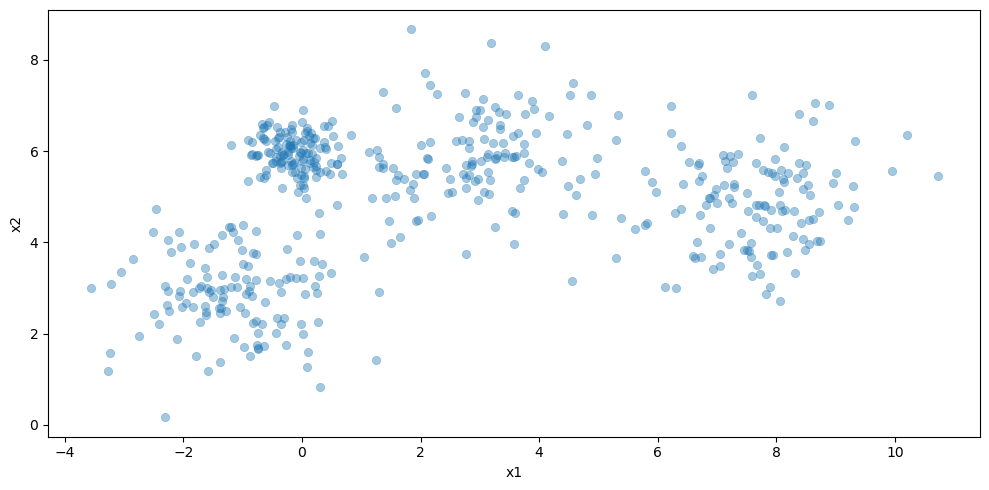

In [79]:
def plot_data(dataframe, **kwargs):

    nrows = kwargs.get('nrows', 1)
    ncols = kwargs.get('ncols', 1)
    width = kwargs.get('width', 11)
    height = kwargs.get('height', 5)
    sharey = kwargs.get('sharey', True)
    sharex = kwargs.get('sharex', True)
    x = kwargs.get('x', 'x1')
    y = kwargs.get('y', 'x2')
    scatter_alpha = kwargs.get('scatter_alpha', 0.4)
    kde_alpha = kwargs.get('kde_alpha', 0.5)
    edgecolor = kwargs.get('edgecolor', None)
    levels = kwargs.get('levels', 10) # kde plot param
    color = kwargs.get('color', 'black') # kde plot param
    linewidths = kwargs.get('linewidths', 0.75) # kde plot param
    add_kde = kwargs.get('add_kde', False)

    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(width, height), sharey=sharey, sharex=sharex)

    sns.scatterplot(data=dataframe, x=x, y=y,
                    alpha=scatter_alpha, edgecolor=edgecolor,
                    ax=ax)
    
    if add_kde:
        sns.kdeplot(data=dataframe, x=x, y=y,
                    alpha=kde_alpha, levels=levels, color=color, linewidths=linewidths,
                    ax=ax)

    plt.tight_layout()
    plt.show()

plot_data(df, nrows=1, ncols=1, width=10, height=5, sharey=True, sharex=True, x='x1', y='x2', alpha=0.4, edgecolor=None)

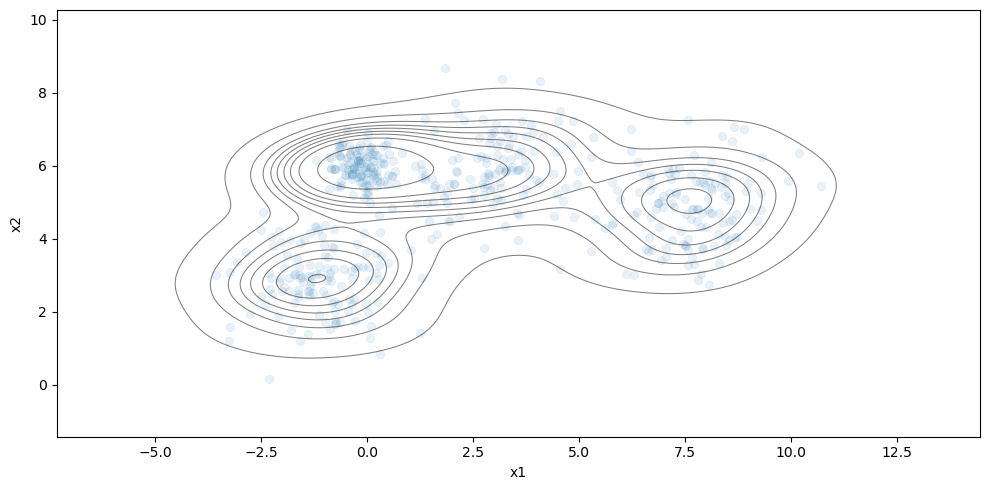

In [80]:
plot_data(df, nrows=1, ncols=1, width=10, height=5, x='x1', y='x2', scatter_alpha=0.1, edgecolor=None, single_plot=False, add_kde=True, kde_alpha=0.5, levels=10, color='black')

## Part 1(f) - Explanation of Data Exploration

Based on the scatterplots above, I estimate there to be 4 clusters in this Cartesian plane. There appears to be a clustering in the lower-left quadrant. Moving clockwise, another, denser clustering lies in the upper-left quadrant--which seems to overlap with a center cluster, then another cluster to the right. This ambiguous overlapping will likely be challenging for some models to accurately distinguish. Additionally, I observe a few anomalies around the cluster borders. 

# Part 2 - Data Preparation

## Part 2(a) - Scaling

In [81]:
df_scaled = StandardScaler().fit_transform(df)

In [82]:
# dataframe of scaled data for plotting

df_scaled_df = pd.DataFrame(df_scaled, columns=['x1', 'x2'])

In [83]:
print(f'The scaled data is now {df_scaled.shape[0]} rows and {df_scaled.shape[1]} columns.')

The scaled data is now 500 rows and 2 columns.


# Part 3 - Identify Potential Outliers

## Part 3(a) - IsoForest Instantiation

In [84]:
iso_forest = IsolationForest(
    n_estimators=1000,
    max_samples=0.5,
    max_features=1.0,
    contamination='auto',
    random_state=415
)

iso_forest.fit(df_scaled)

IsolationForest(max_samples=0.5, n_estimators=1000, random_state=415)

## Part 3(b) - Identifying and Updating Anomaly Assignment Threshold

In [85]:
df['anomaly_score'] = iso_forest.decision_function(df_scaled)
df['iso_forest_pred'] = iso_forest.predict(df_scaled)

In [86]:
anom_score_min = np.floor(df.anomaly_score.min() * 100)
anom_score_max = np.ceil(df.anomaly_score.max() * 100)

bins = np.linspace(anom_score_min, anom_score_max,
                   int(anom_score_max-anom_score_min+1)) / 100

anom_scores_binned = pd.cut(x= df.anomaly_score, bins=bins).value_counts().sort_index(ascending=False).reset_index()

updated_bound = anom_scores_binned.loc[anom_scores_binned['count'].argmin()].anomaly_score.right


## Part 3(c) - Histogram of anomaly scores with updated threshold

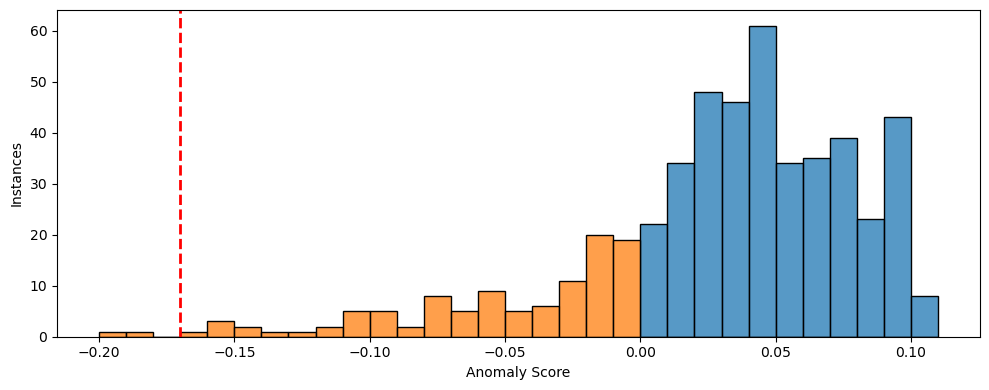

In [87]:
def plot_anomaly_hist(dataframe, **kwargs):
    '''Presents a histogram of the anomaly scores with the updated threshold visualized'''
    nrows = kwargs.get('nrows', 1)
    ncols = kwargs.get('ncols', 1)
    width = kwargs.get('width', 10)
    height = kwargs.get('height', 4)
    hist_x = kwargs.get('hist_x', 'anomaly_score')
    v_line_x = kwargs.get('v_line_x')
    bins = kwargs.get('bins', 'sqrt')
    color = kwargs.get('color', 'r')
    linestyle = kwargs.get('linestyle', '--')
    linewidth = kwargs.get('linewidth', 2)
    x_label = kwargs.get('x_label', 'Anomaly Score')
    y_label = kwargs.get('y_label', 'Instances')

    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(width, height))
    sns.histplot(data=dataframe[dataframe.anomaly_score > 0], x=hist_x, bins=bins, ax=ax)
    sns.histplot(data=dataframe[dataframe.anomaly_score < 0], x=hist_x, bins=bins, ax=ax)
    ax.axvline(x=v_line_x, color=color, linestyle=linestyle, linewidth=linewidth)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    plt.tight_layout()
    plt.show() 

plot_anomaly_hist(df, nrows=1, ncols=1, width=10, height=4, hist_x='anomaly_score', v_line_x=updated_bound, bins=bins, color='r', linestyle= '--', linewidth=2, x_label='Anomaly Score', y_label='Instances')

## Part 3(d) - Presentation of identified outliers
## Part 3(e) - Estimated outliers calculated and displayed as plot title

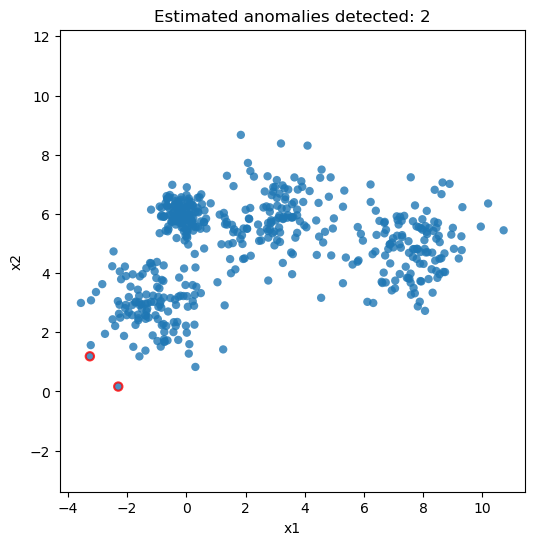

In [88]:
def plot_visible_outliers(dataframe, **kwargs):
    '''Presents a plot of the data with any identified outliers (i.e., outliers) highlighted or marked for clarity
    by overlaying two scatterplots (one with normal datapoints; one with marked anomalies)'''
    nrows=kwargs.get('nrows', 1)
    ncols=kwargs.get('ncols', 1)
    width=kwargs.get('width', 6)
    height=kwargs.get('height', 6)
    x=kwargs.get('x', 'x1')
    y=kwargs.get('y', 'x2')
    outliers = kwargs.get('outliers', 'anomaly_score')
    threshold = kwargs.get('threshold', 0)
    alpha=kwargs.get('alpha', 0.8)
    legend=kwargs.get('legend',False)
    edgecolor = kwargs.get('edgecolor', 'none')
    edgecolors = kwargs.get('edgecolors', 'black')
    facecolors = kwargs.get('facecolors', 'none')
    linewidth = kwargs.get('linewidth', 1.5)
    plt_axis = kwargs.get('plt_axis', 'equal')

    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(width,height))
    sns.scatterplot(data=dataframe, x=x, y=y, alpha=alpha, ax=ax, legend=legend, edgecolor=edgecolor)
    sns.scatterplot(data=dataframe[dataframe['anomaly_score'] <= threshold],
                    x=x,
                    y=y,
                    ax=ax,
                    alpha=alpha,
                    edgecolors=edgecolors, facecolors=facecolors, linewidth=linewidth)
    
    plt.title(f'Estimated anomalies detected: {(dataframe['anomaly_score'] <= threshold).sum()}') # presentation of calculated anomalies
    plt.axis(plt_axis)
    plt.show()


plot_visible_outliers(df, nrows=1, ncols=1, width=6, height=6, x='x1', y='x2', threshold=updated_bound, alpha=0.8, legend=False, edgecolor='none', edgecolors='red', facecolors='none', linewidth=1.5, plt_axis='equal')

## Part 3(f) - Extraction of outlier indices

In [89]:
# extraction via list comprehension
# outlier_indices = [idx for idx, o in df['anomaly_score'].items() if o <= updated_bound]

def outlier_extraction(dataframe, threshold):
    '''Extracts outliers and their indices for reference'''

    # extraction using pandas-native method
    outliers_df = dataframe[dataframe['anomaly_score'] <= threshold]
    indices = outliers_df.index

    # demonstrated dict comprehension for alternative extraction solution
    extracted_outliers = {attribute:value for attribute, value in outliers_df.items()}
    extracted_outliers_df = pd.DataFrame(extracted_outliers)
    display(extracted_outliers_df)

    # returns indices to store in variable for reference throughout pipeline
    return indices

outlier_indices = outlier_extraction(df, updated_bound)

,x1,x2,anomaly_score,iso_forest_pred
66,-2.302869,0.166537,-0.192526,-1
106,-3.262928,1.189069,-0.184567,-1


In [90]:
print(outlier_indices)

Index([66, 106], dtype='int64')


## Part 3(g) - Evaluation of outliers

outlier_1 = {x1:-2.302868958266949,
             x2:0.1665366088317172, 
             anomaly_score: -0.19252558057666158,
             iso_forest_pred:-1
             }

outlier_2 = {x1: -3.2629281466092444,
             x2: 1.189069396018556,
             anomaly_score: -0.18456738177862853,
             iso_forest_pred: -1}

As shown in the dataframe in part 3(f), the two anomalies lie in the lower-left quadrant of the cartesian plane. Consistent with the nature of anomalies, both anomalies share iso_forest_pred scores of -1, though outlier 1 appears to lie further from the rest of the data. By contrast, outlier 2 appears to be placed in closer proximity to the rest of the data. This makes sense given that outlier 1 shows a stronger, more negative anomaly score (-0.19252558057666158) than outlier 2 (-0.18456738177862853), indicating that the isolation forest algorithm took less computation to segment off the further point, i.e., outlier 1. Given that outlier 2 lies so close to the data, the isolation forest algorithm undoubtedly required more computation to segment off this datapoint. 

This dataset comprises 500 instances, so a default threshold score of 0.0 would have aggressively flagged many more anomalies and segmented off a considerable portion of the data. By adjusting the threshold in accordance with the data's distribution, the algorithm identifies the clusters more accurately while flagging anomalies less aggressively.

# Part 4 - K-means Clustering

## Part 4(a) - Identifying optimum number of clusters k using Elbow Method, Silhouette Score, and Davies-Bouldin Score

In [91]:
metrics_per_k = np.empty((0, 6))

for k in np.arange(start=2, stop=21, step=1, dtype=int):

    kmeans = KMeans(n_clusters=k, random_state=415).fit(df_scaled)
    gmm = GaussianMixture(n_components=k, random_state=415).fit(df_scaled)

    metrics_per_k = np.vstack([metrics_per_k,
                               np.array([k,
                                         kmeans.inertia_,
                                         silhouette_score(df_scaled, kmeans.labels_),
                                         davies_bouldin_score(df_scaled, kmeans.labels_),
                                         gmm.aic(df_scaled),
                                         gmm.bic(df_scaled)
                               ])])
    
optimal_k_sil        = metrics_per_k[metrics_per_k[:,2].argmax(), 0]
optimal_k_db     = metrics_per_k[metrics_per_k[:,3].argmin(), 0]

## Part 4(b) - Plotting results for Elbow Method, Silhouette Score, and Davies-Bouldin Score

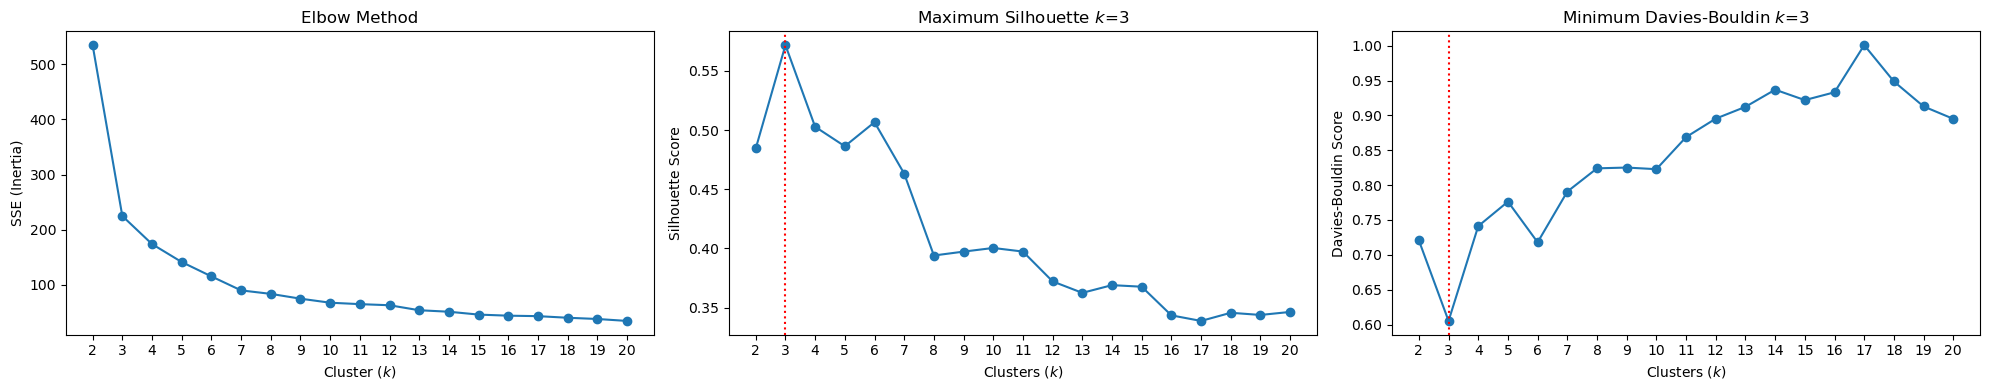

In [92]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20, 4))

# Elbow
ax[0].scatter(x= metrics_per_k[:, 0], y= metrics_per_k[:, 1])
ax[0].plot(metrics_per_k[:, 0], metrics_per_k[:, 1])
ax[0].set_xlabel('Cluster ($k$)')
ax[0].set_ylabel('SSE (Inertia)')
ax[0].set_xticks(ticks= np.arange(2, 21, 1))
ax[0].set_title('Elbow Method')

# Silhouette
ax[1].scatter(x= metrics_per_k[:, 0], y= metrics_per_k[:, 2])
ax[1].plot(metrics_per_k[:, 0], metrics_per_k[:, 2])
ax[1].set_xlabel('Clusters ($k$)')
ax[1].set_ylabel('Silhouette Score')
ax[1].axvline(x= optimal_k_sil, color= 'r', linestyle= ':')
ax[1].set_xticks(ticks= np.arange(2, 21, 1))
ax[1].set_title(f'Maximum Silhouette $k$={int(optimal_k_sil)}')

# Davies-Bouldin
ax[2].scatter(x= metrics_per_k[:, 0], y= metrics_per_k[:, 3])
ax[2].plot(metrics_per_k[:, 0], metrics_per_k[:, 3])
ax[2].set_xlabel('Clusters ($k$)')
ax[2].set_ylabel('Davies-Bouldin Score')
ax[2].axvline(x= optimal_k_db, color= 'r', linestyle= ':')
ax[2].set_xticks(ticks= np.arange(2, 21, 1))
ax[2].set_title(f'Minimum Davies-Bouldin $k$={int(optimal_k_db)}')

plt.tight_layout()
plt.show()

## Part 4(c) - Evaluation of k optimal values

Each plot shows *k* = 3 to be the optimal value. 

The elbow method shows a sharp decrease in slope where *k* <= 3, after which the slope begins to gradually level out as *k* increases. Similarly, the silhouette score shows a peak, while the Davies-Bouldin score shows a valley, where *k* = 3. This indicates that despite there appearing to be four distinguishable groupings during initial assessment of the data in part 1(e), the k-means algorithm actually computed three. 

While a human's pattern recognition might discern four clusters, the k-means algorithm likely grouped two of the more ambiguous clusters with lower densities (i.e., the datapoints in the center and to the right of center). Additionally, there lies a particularly dense grouping in the area left of center, which clearly denotes its own clustering, with a wider spread toward the lower-left quadrant approaching the outliers.

## Part 4(d) - Training K-Means algorithm

In [93]:
kmeans = KMeans(n_clusters=3, init= 'k-means++', random_state=415).fit(df_scaled)

# Part 5 - Gaussian Mixture Model

## Part 5(a) - Identification of optimum number of cluster k via AIC and BIC

In [94]:
optimal_k_aic = metrics_per_k[metrics_per_k[:,4].argmin(), 0]
optimal_k_bic = metrics_per_k[metrics_per_k[:,5].argmin(), 0]

## Part 5(b) - Plotting Optimal AIC/BIC Values

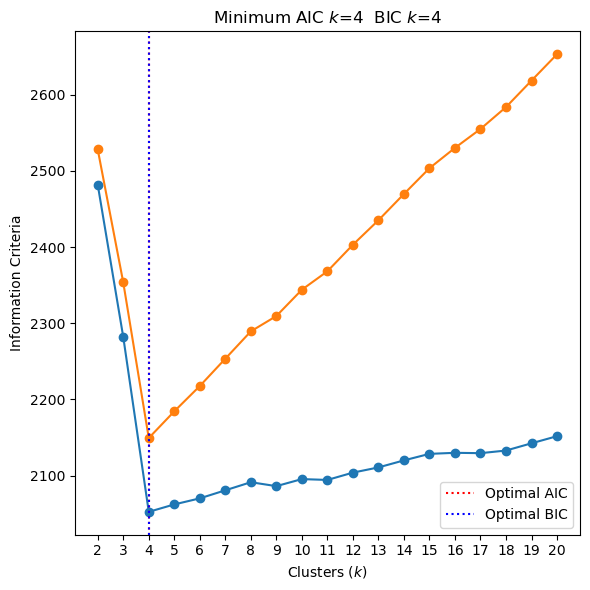

In [95]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,6))

ax.scatter(x= metrics_per_k[:, 0], y= metrics_per_k[:, 4])
ax.plot(metrics_per_k[:, 0], metrics_per_k[:, 4])
ax.scatter(x= metrics_per_k[:, 0], y= metrics_per_k[:, 5])
ax.plot(metrics_per_k[:, 0], metrics_per_k[:, 5])

ax.set_xlabel('Clusters ($k$)')
ax.set_ylabel('Information Criteria')
ax.axvline(x= optimal_k_aic, color= 'r', linestyle= ':', label = f'Optimal AIC')
ax.axvline(x= optimal_k_bic, color= 'b', linestyle= ':', label = f'Optimal BIC')
ax.set_xticks(ticks= np.arange(2, 21, 1))

ax.legend(loc='best')

ax.set_title(f'Minimum AIC $k$={int(optimal_k_aic)}  BIC $k$={int(optimal_k_bic)}')
plt.tight_layout()
plt.show()

## Part 5(c) - Evaluation of Optimal AIC/BIC values

The plot above shows the optimal AIC and BIC value to be *k*=4. This value is clearly higher than the K-means estimated *k* value and more aligned with my initial estimation. By definition, k-means assumes spherical clustering, so it underperforms at capturing the substructural components of this dataset in comparison to the Gaussian Mixture Model (GMM). 

## Part 5(d) - Training Gaussian Mixture Model

In [96]:
k = 4
gmm = GaussianMixture(n_components=k, random_state=415).fit(df_scaled)

# Part 6 - DBSCAN

## Part 6(a) - Selection of min_samples hyperparameter

In [97]:
min_samples = 2 * df_scaled.shape[1]
print(f'min_samples: {min_samples}')

min_samples: 4


## Part 6(b) - Identification of optimal value for *eps* hyperparameter

Optimal eps: 0.213185


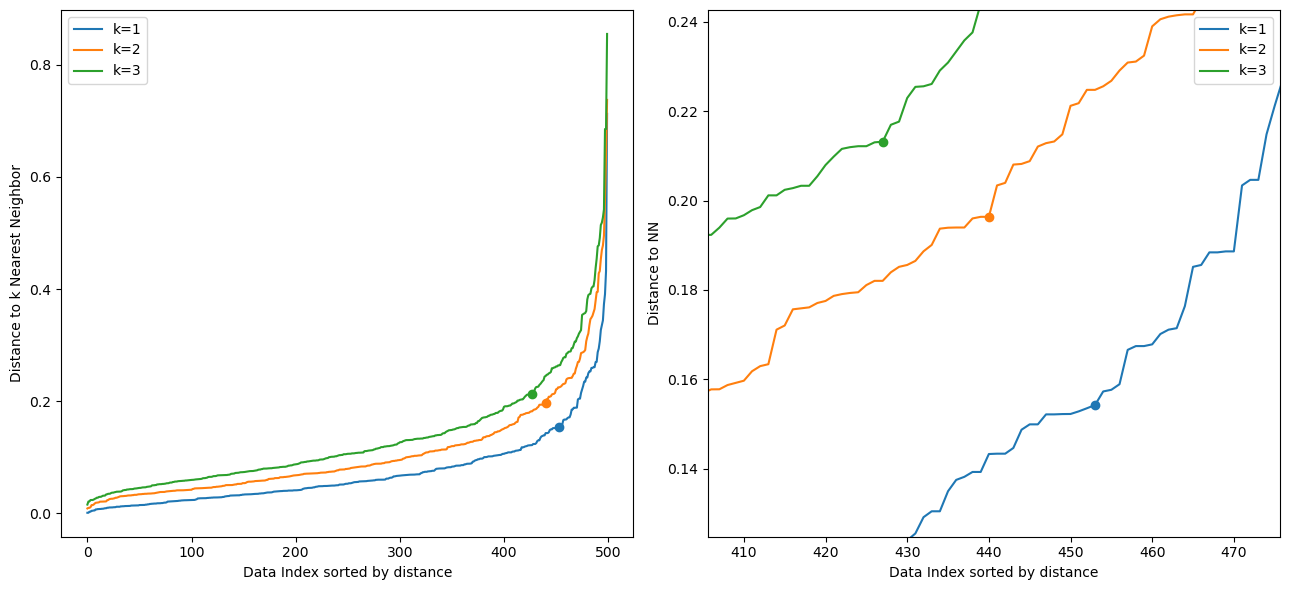

In [98]:
neighborhood_size=min_samples
nbrs = NearestNeighbors(n_neighbors=neighborhood_size).fit(df_scaled)
distances, indices = nbrs.kneighbors(df_scaled)

opt_eps_minpts = np.empty((0, 3))
fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(13, 6))

for k in np.arange(1, neighborhood_size):

    # Calculate distance to kth nearest neighbor (knn)
    knn_distances = np.sort(distances[:, k])

    # Scale knn to [0, 1]
    scaled_knn_dists = (knn_distances - knn_distances.min()) / (knn_distances.max() - knn_distances.min())

    # Scale indices to [0, 1]
    scaled_idx = np.linspace(start=0, stop=1, num=int(scaled_knn_dists.shape[0]))

    knn_coords = np.concatenate([scaled_idx, scaled_knn_dists]).reshape(2, -1).T
    line_coords = np.concatenate([scaled_idx, scaled_idx]).reshape(2, -1).T

    line_to_knn_dists = cdist(XA=knn_coords, XB=line_coords)
    idx_opt = line_to_knn_dists.min(axis=1).argmax()

    opt_eps_minpts = np.vstack([opt_eps_minpts, np.array([k, idx_opt, knn_distances[idx_opt]])])

    ax0.plot(knn_distances, label=f'k={k}')
    ax0.scatter(x=idx_opt, y=knn_distances[idx_opt])

    ax1.plot(knn_distances, label=f'k={k}')
    ax1.scatter(x=idx_opt, y=knn_distances[idx_opt])

opt_eps = knn_distances[idx_opt]

print(f'Optimal eps: {opt_eps:.6f}')   

eps_delta = opt_eps_minpts[:, 2].max() - opt_eps_minpts[:, 2].min()

ax0.legend()
ax0.set_xlabel(f'Data Index sorted by distance')
ax0.set_ylabel(f'Distance to k Nearest Neighbor')

ax1.set_xlim([opt_eps_minpts[:, 1].min()*0.95,
              opt_eps_minpts[:, 1].max()*1.05])

ax1.set_ylim([opt_eps_minpts[:, 2].min() - 0.5*eps_delta,
              opt_eps_minpts[:, 2].max() + 0.5*eps_delta])

ax1.legend()
ax1.set_xlabel(f'Data Index sorted by distance')
ax1.set_ylabel(f'Distance to NN')

plt.tight_layout()
plt.show()

## Part 6(c) - Training DBSCAN algorithm

In [99]:
dbscan = DBSCAN(min_samples=neighborhood_size, eps=opt_eps).fit(df_scaled)

## Part 6(d) - Identification and presentation of number of outliers from DBSCAN clusterer

In [100]:
labels_db = dbscan.labels_
clstr, cnts = np.unique(dbscan.labels_, return_counts=True)

print(f'Number of Clusters: {(clstr != -1).sum()} | Number of Outliers: {cnts[clstr == -1][0]}')

Number of Clusters: 5 | Number of Outliers: 44


## Part 6(e) - Plotting clusters identified by DBSCAN

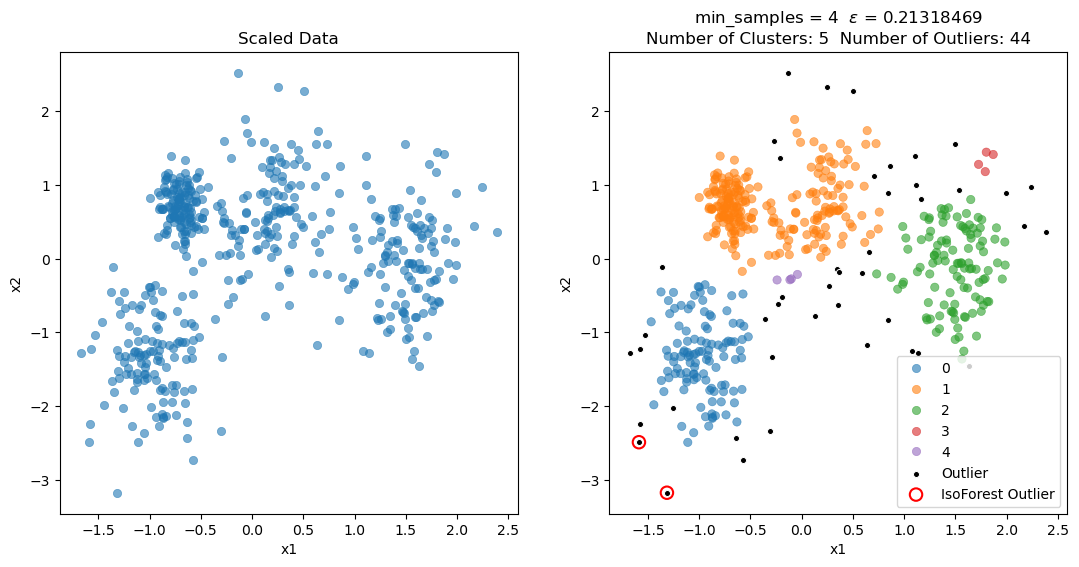

In [101]:
fig, ax = plt.subplots(nrows= 1, ncols= 2, figsize= (13, 6))
sns.scatterplot(x= df_scaled_df.x1, y= df_scaled_df.x2, alpha= 0.6, ax= ax[0], edgecolor= None)
ax[0].set_title('Scaled Data')

sns.scatterplot(data= df_scaled_df[dbscan.labels_ > -1], x= 'x1', y= 'x2', 
                hue= labels_db[dbscan.labels_ > -1], 
                alpha= 0.6, palette= 'tab10', ax= ax[1], edgecolor= None)
sns.scatterplot(data= df_scaled_df[dbscan.labels_ == -1], x= 'x1', y= 'x2', 
                color= 'black', marker= '.', s= 75, label= 'Outlier',
                ax= ax[1])
sns.scatterplot(data=df_scaled_df.loc[outlier_indices], x='x1', y='x2',
                ax=ax[1], edgecolors='red', facecolors='none',
                linewidth=1.5, s=80, zorder=5, label='IsoForest Outlier')
ax[1].set_title(f'min_samples = {int(opt_eps_minpts[-1, 0] + 1)}  $\\epsilon$ = {np.round(opt_eps_minpts[-1, 2], 8)}\nNumber of Clusters: {(clstr != -1).sum()}  Number of Outliers: {cnts[clstr == -1][0]}')
plt.show()

## Part 6(f) - Evaluation of DBSCAN clustering

The plot above shows that DBSCAN identified five clusters and 44 outliers, 22x as many outliers as the Isolation Forest algorithm detection. The outliers identified by the Isolation Forest algorithm are circled in red; these appear to be actual outliers based on their placement and the fact that they are sequestered from the rest of the data. 

Some of the outliers found by DBSCAN appear to be actual outliers, as they lie on the borders of the dataset and appear to have fewer core neighbors; however, a few of the detected outliers could easily be grouped. Increasing the epsilon value to widen its radius would likely reduce the number of outliers, especially toward the center of the data and other denser areas.

Most of the datapoints fall into three rather large clusters--as reflected by the blue, orange, and green clusterings. However, the additional two clusters (the purple below the orange; and red above the green) reflect only a few datapoints. 


## Part 6(g) - Removal of outlier instances

In [102]:
df_scaled_clean = df_scaled[dbscan.labels_ != -1].copy()
print(f'Clean dataset shape: {df_scaled_clean.shape}')

Clean dataset shape: (456, 2)


# Part 7 - Model Evaluation and Selection

## Part 7(a) - Plotting Optimized clustering models

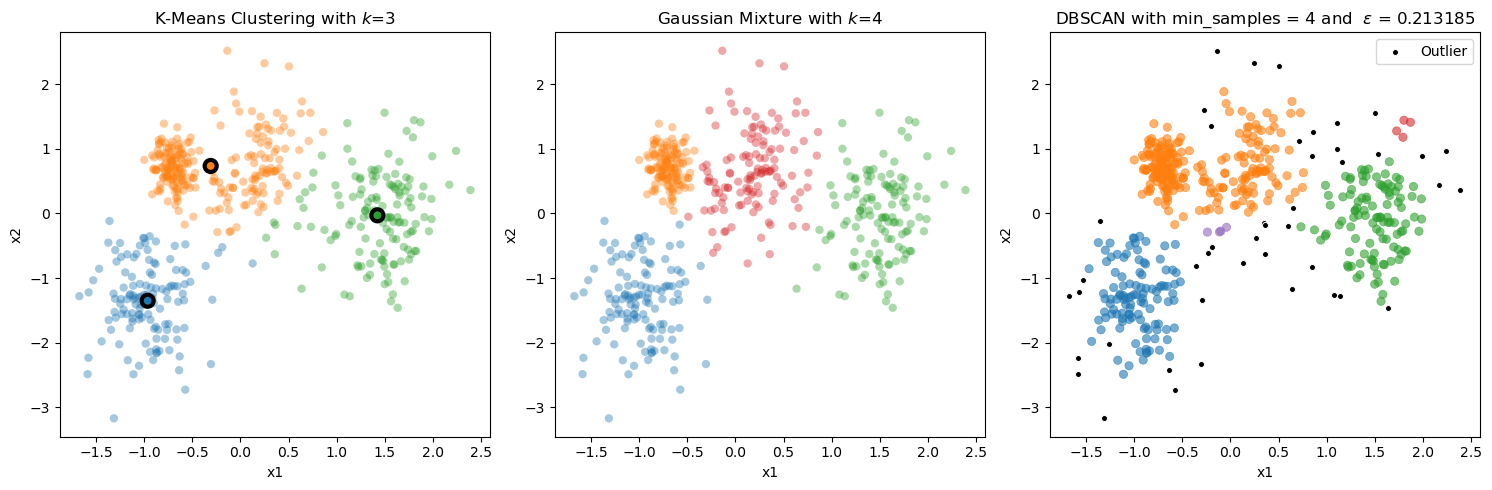

In [103]:
gmm_labels = gmm.predict(df_scaled)

fig, ax = plt.subplots(nrows= 1, ncols= 3, figsize= (15, 5))  

# KMeans
sns.scatterplot(data= df_scaled_df, x= 'x1', y= 'x2', alpha= 0.4,
                hue= kmeans.labels_, palette= 'tab10', edgecolor= 'none',
                ax= ax[0], legend= False)
sns.scatterplot(x= kmeans.cluster_centers_[:, 0], y= kmeans.cluster_centers_[:, 1],
                hue= np.unique(kmeans.labels_), palette= 'tab10',
                s= 75, edgecolor= 'black', ax= ax[0], linewidth= 3, legend= False)
ax[0].set_title(f'K-Means Clustering with $k$=3')

# GMM
sns.scatterplot(data=df_scaled_df, x='x1', y='x2', hue=gmm_labels,
                alpha=0.4, palette='tab10', edgecolor='none', ax=ax[1], legend=False)
ax[1].set_title(f'Gaussian Mixture with $k$=4')

# DBSCAN

sns.scatterplot(data= df_scaled_df[dbscan.labels_ > -1], x= 'x1', y= 'x2', 
                hue= labels_db[dbscan.labels_ > -1], 
                alpha= 0.6, palette= 'tab10', ax= ax[2], edgecolor= None,
                legend= False)
sns.scatterplot(data= df_scaled_df[dbscan.labels_ == -1], x= 'x1', y= 'x2', 
                marker= '.', s= 75, color= 'black', ax= ax[2], label= 'Outlier')
ax[2].set_title(f'DBSCAN with min_samples = {int(opt_eps_minpts[-1, 0] + 1)} and  $\\epsilon$ = {opt_eps_minpts[-1, 2]:.6f}')
plt.tight_layout()
plt.show()

## Part 7(b) - Evaluation of Model Plot Comparison

As shown by the plot above, the k-means algorithm detects three clusters (blue, orange, and green), though human pattern-recognition would likely detect four. The orange cluster appears to be an aggregate of a smaller, denser cluster and its larger, lighter counterpart. As noted previously, the k-means algorithm assumes spherical clustering, which likely explains the geometry of the three cluster groups. 

The Gaussian Mixture Model detects four clusters (blue, orange, red, and green), which is concordant with the initial estimate from part 1(f). This model seems to fit the dataset well, accounting for its distribution without imposing any geometrical assumptions. Neither the k-means nor the Gaussian Mixture model indicate presence of any noise.

The DBSCAN model identifies five clusters with forty-four outliers. As mentioned previously, the clusters are grouped in blue, orange, purple, green, and red; the purple and red clusters are significantly smaller than their larger counterparts. The outliers, displayed in black, are scattered throughout the dataset. This suggests the sensitivity of the DBSCAN algorithm; increasing *epsilon* would likely reduce noise and decrease the number of detected clusters. The red and purple clusters would likely be classified as part of the orange and green clusters, respectively. However, the red cluster appears to lie slightly further from the rest of the data in comparison to the proximity of the purple cluster. 

## Part 7(c) - Calculating the Silhouette and Davies-Bouldin Scores for each clustering

In [104]:
print(f'{'METHOD':<6}{'Silhouette Score':>20}{'Davies-Bouldin Score':>24}')
print(f'{'KMEANS':<6}{silhouette_score(X= df_scaled, labels= kmeans.labels_):>20.5f}{davies_bouldin_score(X= df_scaled, labels= kmeans.labels_):>24.5f}')

print(f'{'GMM':<6}{silhouette_score(X= df_scaled, labels= gmm_labels):>20.5f}{davies_bouldin_score(X= df_scaled, labels= gmm_labels):>24.5f}')

print(f'{'DBSCAN':<6}{silhouette_score(X= df_scaled_clean, labels= dbscan.labels_[dbscan.labels_ != -1]):>20.5f}{davies_bouldin_score(X= df_scaled_clean, labels= labels_db[dbscan.labels_ != -1]):>24.5f}')

METHOD    Silhouette Score    Davies-Bouldin Score
KMEANS             0.57186                 0.60515
GMM                0.48983                 0.78507
DBSCAN             0.36515                 0.53838


## Part 7(d) - Assessment of clustering methods per evaluation metric

With regard to the Silhouette scores, the KMEANS algorithm reigned champion (0.57186); the GMM followed with a score of 0.48983; the DBSCAN showed the lowest with a score of 0.36515. This makes sense given that the K-Means model detected three clusterings. By definition, Silhouette scores measure intra-clustering similarity. Three clusterings indicates tighter packing of datapoints around their centroids. Given that the GMM detected four clusters, this model is implying that there is less overlap between clusters. Though DBSCAN identified reasonable intra-cluster density, its noise-detection might be negatively impacting its Silhouette score in comparison to the K-Means and GMM models. 

With regard to the Davies-Bouldin scores, DBSCAN showed the optimal score (0.53838), while K-Means showed a slightly less optimal score at 0.60515. GMM showed the worst score (0.78507). The Davies-Bouldin score measures inter-cluster similarity. The more optimal score of the DBSCAN is concordant with its detection of 5 clusters, indicating that the model precisely classified more clusters based on their differences. 